# Toxic Comment Detection using Python

**Project title:** Toxic Comment Detection (Jigsaw Kaggle dataset)

This notebook demonstrates a professional college-style ML project workflow:
- Problem definition and dataset overview
- Data exploration and preprocessing
- Feature extraction using TF-IDF
- Logistic Regression training and evaluation
- Visualizations and deployment-ready prediction function

**Goal:** Build a binary classifier to identify toxic vs non-toxic comments.

## 1. Project Introduction

In this micro project, we classify comments as toxic or non-toxic by building a text classification pipeline.
We will go through data loading, exploration, preprocessing, vectorization, model training, and evaluation.

## 2. Import Libraries

Import required Python libraries for data analysis, visualization, NLP preprocessing, and modeling.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import re

# Download NLTK data if needed
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fadisulaiman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fadisulaiman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 3. Load Dataset

Load the Jigsaw dangerous comment dataset and inspect key information.

In [21]:
# Load and inspect the training dataset
df = pd.read_csv('dataset/train.csv')
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())

# Display first 5 rows for quick view
df.head()

Dataset shape: (159571, 8)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 4. Data Exploration

We explore data quality, class distribution, and relevant columns.

Missing values by column:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64
Using text column: comment_text
Using target column: binary_toxic

First 5 rows:
                                        comment_text  toxic  severe_toxic  \
0  Explanation\nWhy the edits made under my usern...      0             0   
1  D'aww! He matches this background colour I'm s...      0             0   
2  Hey man, I'm really not trying to edit war. It...      0             0   
3  "\nMore\nI can't make any real suggestions on ...      0             0   
4  You, sir, are my hero. Any chance you remember...      0             0   

   obscene  threat  insult  identity_hate  binary_toxic  
0        0       0       0              0             0  
1        0       0       0              0             0  
2        0       0       0              0             0  
3        0       0       0       

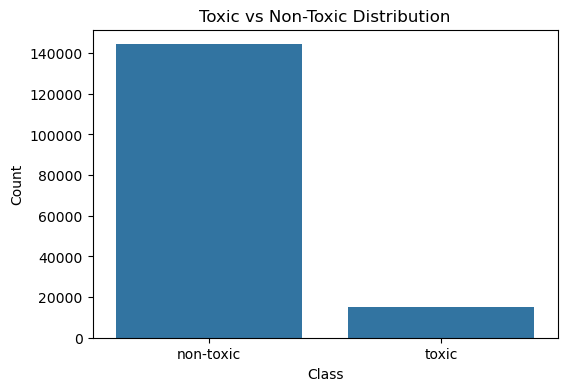

In [22]:
# Check missing values and dataset dimensions
print('Missing values by column:')
print(df.isnull().sum())

# Define feature and target columns
text_col = 'comment_text' if 'comment_text' in df.columns else ('text' if 'text' in df.columns else df.columns[0])

df['binary_toxic'] = df['toxic'].apply(lambda x: 1 if x == 1 else 0)
target_col = 'binary_toxic'

print('Using text column:', text_col)
print('Using target column:', target_col)

# Display sample rows
print('\nFirst 5 rows:')
print(df[[text_col, 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', target_col]].head())

# Show dataset info for column types and non-null counts
print('\nDataset info:')
df.info()

# Show and plot class distribution
print('\nDistribution toxic vs non-toxic:')
print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title('Toxic vs Non-Toxic Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0,1], ['non-toxic', 'toxic'])
plt.show()

## 5. Data Preprocessing

We now preprocess text for modeling: lowercasing, URL removal, punctuation removal, numbers removal, stopword filtering, and tokenization.

In [23]:
# Keep only relevant columns and drop any null values
df = df[[text_col, target_col]].copy()
df = df.dropna().reset_index(drop=True)

# Apply text preprocessing to create cleaned text features
def clean_text(text):
    text = str(text).lower()  # Lowercase text
    text = re.sub(r'http\S+|www\S+', ' ', text)  # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)  # Remove punctuation and digits
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]  # Remove stopwords
    return ' '.join(tokens)

stop_words = set(stopwords.words('english'))
df['clean_comment'] = df[text_col].apply(clean_text)

print('Sample cleaned comments:')
df[[text_col, 'clean_comment', target_col]].head()

Sample cleaned comments:


,comment_text,clean_comment,binary_toxic
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...,0
1,D'aww! He matches this background colour I'm s...,aww matches background colour seemingly stuck ...,0
2,"Hey man, I'm really not trying to edit war. It...",hey man really trying edit war guy constantly ...,0
3,"""\nMore\nI can't make any real suggestions on ...",make real suggestions improvement wondered sec...,0
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page,0


## 6. Feature Extraction using TF-IDF

Feature extraction converts text into numeric vectors using TF-IDF.

Convert cleaned comments into numerical vectors using TF-IDF.

In [24]:
# TF-IDF vectorization with max 5000 features and English stopwords removed
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_comment'])
y = df[target_col].values
print('Feature matrix shape:', X.shape)
print('Sample vector size:', X[0].shape)
print('Number of classes:', np.unique(y))

Feature matrix shape: (159571, 5000)
Sample vector size: (1, 5000)
Number of classes: [0 1]


## 8. Train-Test Split

Split the feature matrix into training and test sets (80/20 split).

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (127656, 5000)
Test shape: (31915, 5000)


## 9. Train Machine Learning Model

Train a Logistic Regression classifier using the training split.

In [26]:
model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 10. Model Evaluation (Accuracy + Confusion Matrix)

Evaluate model performance on the holdout test set.

In [27]:
# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print('Confusion Matrix:')
print(cm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9570
Confusion Matrix:
[[28678   178]
 [ 1195  1864]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28856
           1       0.91      0.61      0.73      3059

    accuracy                           0.96     31915
   macro avg       0.94      0.80      0.85     31915
weighted avg       0.96      0.96      0.95     31915



## 11. Visualization using Matplotlib

Visualize the confusion matrix and class distribution.

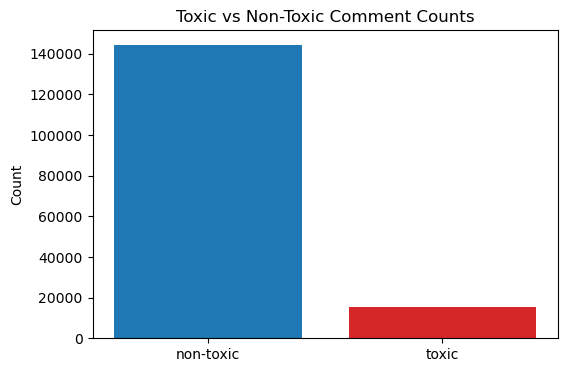

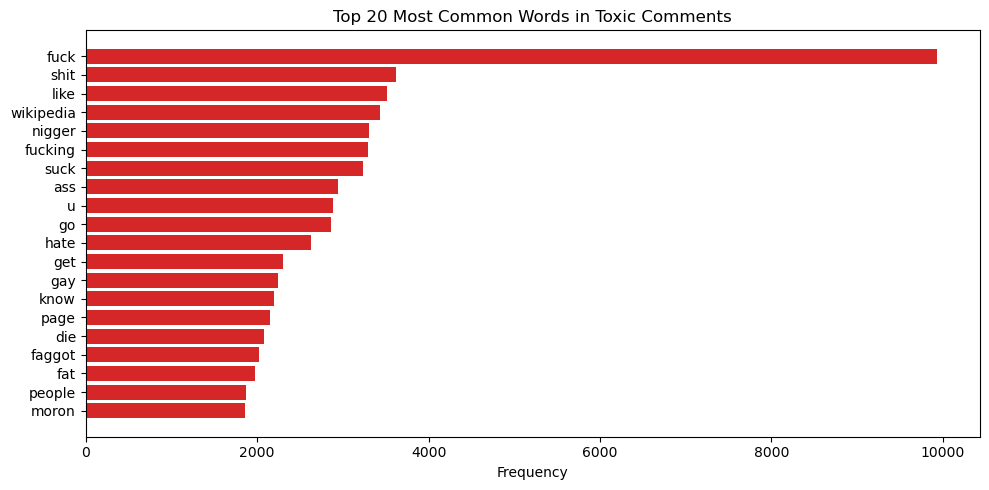

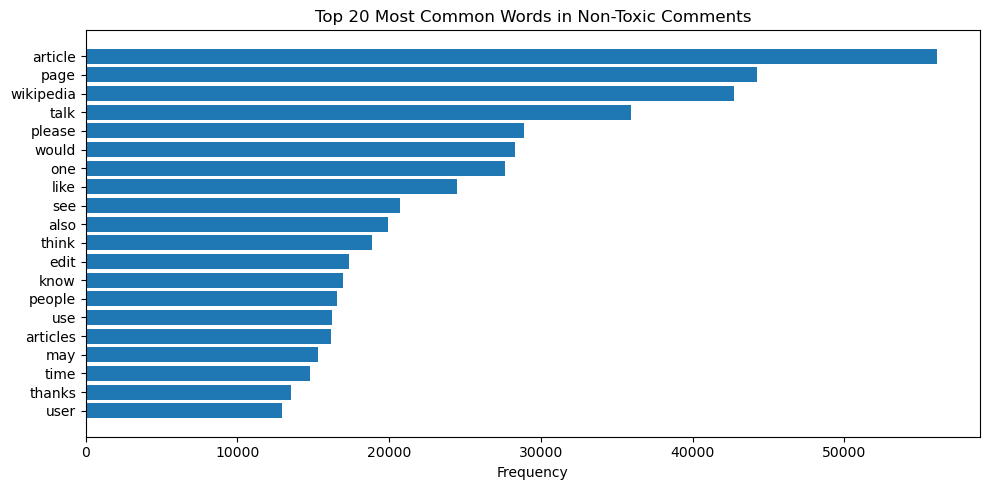

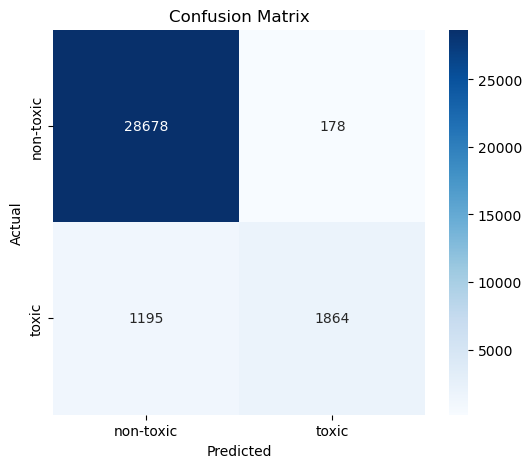

In [28]:
# 1) Bar chart toxic vs non-toxic counts
counts = df[target_col].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(['non-toxic', 'toxic'], counts.values, color=['tab:blue', 'tab:red'])
plt.title('Toxic vs Non-Toxic Comment Counts')
plt.ylabel('Count')
plt.show()

# 2) Top 20 common words in toxic and non-toxic comments
from collections import Counter

toxic_comments = ' '.join(df[df[target_col] == 1]['clean_comment'].tolist())
non_toxic_comments = ' '.join(df[df[target_col] == 0]['clean_comment'].tolist())

toxic_words = Counter(toxic_comments.split())
non_toxic_words = Counter(non_toxic_comments.split())

toxic_top = toxic_words.most_common(20)
non_toxic_top = non_toxic_words.most_common(20)

# Plot top 20 toxic words
plt.figure(figsize=(10,5))
words, freqs = zip(*toxic_top)
plt.barh(words[::-1], freqs[::-1], color='tab:red')
plt.title('Top 20 Most Common Words in Toxic Comments')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# Plot top 20 non-toxic words
plt.figure(figsize=(10,5))
words, freqs = zip(*non_toxic_top)
plt.barh(words[::-1], freqs[::-1], color='tab:blue')
plt.title('Top 20 Most Common Words in Non-Toxic Comments')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# Confusion matrix for model
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['non-toxic','toxic'], yticklabels=['non-toxic','toxic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 12. Prediction Function for new comments

Define a function to predict whether a new comment is toxic or not.

In [29]:
def predict_comment(text):
    """Predict toxicity for a single comment text."""
    cleaned = clean_text(text)  # Reuse preprocessing
    vect = tfidf.transform([cleaned])  # Vectorize
    pred = model.predict(vect)[0]  # Predict label
    label = 'Toxic' if pred == 1 else 'Non-Toxic'
    print(f'Input comment: "{text}"\nPrediction: {label}\n')

# Example predictions for new comments
example_comments = [
    'You are amazing',
    'You are so stupid'
]
for comment in example_comments:
    predict_comment(comment)

Input comment: "You are amazing"
Prediction: Non-Toxic

Input comment: "You are so stupid"
Prediction: Toxic



## 13. Conclusion

We built a toxic comment detection model using TF-IDF and Logistic Regression. The pipeline includes preprocessing, model training, evaluation, and inference for new comments.
Future improvements include using more advanced NLP models, handling class imbalance, and hyperparameter tuning.